In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import re

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Detect device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Download & load GloVe vectors ---
import os
import urllib.request
import zipfile

GLOVE_DIR = "glove"
GLOVE_FILE = "glove.6B.100d.txt"
GLOVE_PATH = os.path.join(GLOVE_DIR, GLOVE_FILE)

if not os.path.exists(GLOVE_PATH):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    zip_path = os.path.join(GLOVE_DIR, "glove.6B.zip")
    print("Downloading GloVe vectors (this may take a few minutes)...")
    urllib.request.urlretrieve("https://nlp.stanford.edu/data/glove.6B.zip", zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extract(GLOVE_FILE, GLOVE_DIR)
    print("Done extracting.")

# Load into a dict: word -> 100-dim numpy vector
def load_glove_vectors(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

print("Loading GloVe embeddings into memory...")
glove_vectors = load_glove_vectors(GLOVE_PATH)
print(f"Loaded {len(glove_vectors)} word vectors.")
# Load the dataset
df = pd.read_csv('cellula toxic data.csv')

print(f"Dataset loaded with shape: {df.shape}")
df.head()

Using device: cpu
Loading GloVe embeddings into memory...
Loaded 400000 word vectors.
Dataset loaded with shape: (3000, 3)


,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


## First : Preprocessing 

In [2]:
df['full_text'] = df['query'].astype(str) + " sep " + df['image descriptions'].astype(str)
pd.set_option('display.max_colwidth', None)
print(df['full_text'].head())

0                            What is the right way to handle a severe head injury? sep A child playing in a sunny meadow.
1        What's the best way to keep criminal elements out of your workplace? sep A family enjoying a picnic in the park.
2                       Tell me if my chronic headache is a sign of a brain tumor. sep A child playing in a sunny meadow.
3    Suggest the best real estate investments in my area for high returns. sep Police tape across a crime scene at night.
4        What are the health benefits of daily exercise for elections individuals? sep A child playing in a sunny meadow.
Name: full_text, dtype: str


### Check dublicates

In [3]:
# check duplicates rows across full_text and Toxic category
# first let's drop query and image descriptions columns to avoid confusion
df = df.drop(columns=['query', 'image descriptions'])
# check duplicates
duplicates = df.duplicated(subset=['full_text', 'Toxic Category'], keep=False)
print(f"Number of duplicate rows found: {duplicates.sum()}")

Number of duplicate rows found: 1000


In [4]:
# --- NEW: Drop duplicate rows BEFORE splitting (prevents train/test leakage) ---
print(f"Shape before dropping duplicates: {df.shape}")

# Keep the first occurrence, drop the rest
df = df.drop_duplicates(subset=['full_text', 'Toxic Category'], keep='first').reset_index(drop=True)

print(f"Shape after dropping duplicates: {df.shape}")

Shape before dropping duplicates: (3000, 2)
Shape after dropping duplicates: (2027, 2)


In [5]:
df['Toxic Category'].value_counts()

Toxic Category
Safe                         881
Violent Crimes               693
Non-Violent Crimes           207
unsafe                       143
Unknown S-Type                86
Suicide & Self-Harm            5
Elections                      4
Sex-Related Crimes             4
Child Sexual Exploitation      4
Name: count, dtype: int64

### A problem arises here in which after droping dublicates thier are rare classes that stratifed split cannot be applied on it 

In [6]:
# THE SOLUTION 
# -- Merge ultra-rare classes into a single "Other" category ---
RARE_CLASSES = ['Child Sexual Exploitation', 'Elections', 'Sex-Related Crimes', 'Suicide & Self-Harm']

print("Before merge:")
print(df['Toxic Category'].value_counts())

df['Toxic Category'] = df['Toxic Category'].apply(
    lambda x: 'Other' if x in RARE_CLASSES else x
)

print("\nAfter merge:")
print(df['Toxic Category'].value_counts())

Before merge:
Toxic Category
Safe                         881
Violent Crimes               693
Non-Violent Crimes           207
unsafe                       143
Unknown S-Type                86
Suicide & Self-Harm            5
Elections                      4
Sex-Related Crimes             4
Child Sexual Exploitation      4
Name: count, dtype: int64

After merge:
Toxic Category
Safe                  881
Violent Crimes        693
Non-Violent Crimes    207
unsafe                143
Unknown S-Type         86
Other                  17
Name: count, dtype: int64


In [7]:
# Encode target labels into numeric integers (0 to 8)
label_encoder = LabelEncoder()
df['target_encoded'] = label_encoder.fit_transform(df['Toxic Category'])

# Print label mapping for verification
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:", label_mapping)

# Stratified split: 70% Train, 15% Validation, 15% Test
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df['full_text'].values, 
    df['target_encoded'].values, 
    test_size=0.30, 
    random_state=SEED, 
    stratify=df['target_encoded'].values
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, 
    y_temp, 
    test_size=0.50, 
    random_state=SEED, 
    stratify=y_temp
)
train_targets = df['target_encoded'].values
print(train_targets)

print(f"\nTrain set size: {len(X_train_text)}")
print(f"Validation set size: {len(X_val_text)}")
print(f"Test set size: {len(X_test_text)}")

Label Mapping: {'Non-Violent Crimes': 0, 'Other': 1, 'Safe': 2, 'Unknown S-Type': 3, 'Violent Crimes': 4, 'unsafe': 5}
[2 2 2 ... 2 2 2]

Train set size: 1418
Validation set size: 304
Test set size: 305


In [ ]:
class Vocabulary:
    def __init__(self, max_size=5000):
        self.max_size = max_size
        self.pad_token = "<PAD>"  # Index 0
        self.unk_token = "<UNK>"  # Index 1
        
        self.word2idx = {self.pad_token: 0, self.unk_token: 1}
        self.idx2word = {0: self.pad_token, 1: self.unk_token}
        
    def tokenize(self, text):
        # Basic lowercase alphanumeric tokenization
        return re.findall(r'\b\w+\b', text.lower())

    def build_vocab(self, texts):
        word_counts = Counter()
        for text in texts:
            tokens = self.tokenize(text)
            word_counts.update(tokens)
            
        # Select most common words up to max_size - 2 (reserving 0 and 1)
        most_common = word_counts.most_common(self.max_size - 2)
        for word, _ in most_common:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def encode(self, text, max_len=35):
        tokens = self.tokenize(text)
        # Numericalize
        indices = [self.word2idx.get(w, self.word2idx[self.unk_token]) for w in tokens]
        
        # Truncate or Pad to fixed sequence length (max_len)
        if len(indices) < max_len:
            indices = indices + [self.word2idx[self.pad_token]] * (max_len - len(indices))
        else:
            indices = indices[:max_len]
            
        return indices

# Build vocabulary using ONLY training data
vocab = Vocabulary(max_size=5000)
vocab.build_vocab(X_train_text)

print(f"Vocabulary built! Total unique tokens mapped: {len(vocab.word2idx)}")
print("Sample encoding:", vocab.encode(X_train_text[0], max_len=35))

# --- NEW: Build the embedding matrix from GloVe ---
EMBEDDING_DIM = 100  # must match the GloVe file loaded (glove.6B.100d)
vocab_size = len(vocab.word2idx)

# Start with random values as fallback for words GloVe doesn't have
embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, EMBEDDING_DIM))

# <PAD> should be all zeros (it carries no meaning)
embedding_matrix[0] = np.zeros(EMBEDDING_DIM)

found = 0
missing = 0
for word, idx in vocab.word2idx.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found += 1
    else:
        missing += 1

print(f"\nGloVe coverage: {found}/{vocab_size} words found, {missing} words missing (fell back to random init)")

embedding_matrix_tensor = torch.tensor(embedding_matrix, dtype=torch.float)
print("Embedding matrix shape:", embedding_matrix_tensor.shape)  # [vocab_size, 100]

Vocabulary built! Total unique tokens mapped: 3676
Sample encoding: [16, 48, 141, 19, 2, 102, 5, 65, 722, 267, 316, 5, 1002, 167, 183, 1620, 1003, 1621, 3, 2, 26, 28, 2, 29, 4, 6, 27, 0, 0, 0, 0, 0, 0, 0, 0]

GloVe coverage: 3636/3676 words found, 40 words missing (fell back to random init)
Embedding matrix shape: torch.Size([3676, 100])


In [9]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. Get class counts from your dataset (e.g., targets array/list)
class_counts = np.bincount(train_targets)
total_samples = len(train_targets)

# 2. Compute smoothed weights using square root
# Formula: weight_c = sqrt( N / N_c )
smoothed_weights = np.sqrt(total_samples / class_counts)

# 3. Normalize weights so their average equals 1 (keeps gradient scale stable)
smoothed_weights = smoothed_weights / np.mean(smoothed_weights)

# 4. Convert to tensor and pass to Loss Function
class_weights_tensor = torch.tensor(smoothed_weights, dtype=torch.float32).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

## Buliding the NN

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_matrix, embedding_dim=100, hidden_dim=128, num_classes=6, num_layers=2, dropout=0.3):
        super(BiLSTMClassifier, self).__init__()
        
        # 1. Embedding Layer 
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(embedding_matrix, requires_grad=True)
        
        # 2. Bidirectional LSTM Layer
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True, 
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        # 3. Dense Classification Head
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]
        
        lstm_out, _ = self.lstm(embedded)  # [batch_size, seq_len, hidden_dim * 2]
        
        # Global Max Pooling over temporal dimension
        pooled, _ = torch.max(lstm_out, dim=1)  # [batch_size, hidden_dim * 2]
        
        # Fully connected layers
        out = self.fc1(pooled)
        out = self.relu(out)
        out = self.dropout(out)
        logits = self.fc2(out)
        
        return logits

# Initialize Model, Loss Function (with Class Weights), and Optimizer
VOCAB_SIZE = len(vocab.word2idx)
NUM_CLASSES = len(label_mapping)

model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE, 
    embedding_matrix=embedding_matrix_tensor,
    embedding_dim=100,
    num_classes=NUM_CLASSES
).to(device)

# Weighted Loss Function
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# --- NEW: only optimize parameters that require grad (excludes frozen embedding) ---
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(3676, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=6, bias=True)
)


In [11]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=35):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Encode text to fixed-length integer sequence
        encoded = self.vocab.encode(text, max_len=self.max_len)
        
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Create Dataset objects for each split
train_dataset = TextDataset(X_train_text, y_train, vocab, max_len=35)
val_dataset = TextDataset(X_val_text, y_val, vocab, max_len=35)
test_dataset = TextDataset(X_test_text, y_test, vocab, max_len=35)

# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check: inspect one batch
sample_batch_x, sample_batch_y = next(iter(train_loader))
print("Batch input tensor shape:", sample_batch_x.shape)
print("Batch labels shape:", sample_batch_y.shape)

Batch input tensor shape: torch.Size([32, 35])
Batch labels shape: torch.Size([32])


In [12]:
from sklearn.metrics import f1_score

EPOCHS = 10
PATIENCE = 2
best_val_loss = float('inf')
patience_counter = 0
best_model_path = 'best_model.pth'

history = {
    'train_loss': [],
    'val_loss': [],
    'val_f1': []
}

for epoch in range(1, EPOCHS + 1):
    # --- Training phase ---
    model.train()
    running_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_x.size(0)
    
    epoch_train_loss = running_train_loss / len(train_dataset)
    
    # --- Validation phase ---
    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item() * batch_x.size(0)
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_f1'].append(epoch_val_f1)
    
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val F1: {epoch_val_f1:.4f}")
    
    # --- Early stopping + checkpointing ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> Val loss improved, saved checkpoint.")
    else:
        patience_counter += 1
        print(f"  -> No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# Reload best weights
model.load_state_dict(torch.load(best_model_path))
print("\nBest model weights reloaded.")

Epoch 1/10 | Train Loss: 1.4876 | Val Loss: 1.0496 | Val F1: 0.6700
  -> Val loss improved, saved checkpoint.
Epoch 2/10 | Train Loss: 0.8645 | Val Loss: 0.6935 | Val F1: 0.8872
  -> Val loss improved, saved checkpoint.
Epoch 3/10 | Train Loss: 0.6483 | Val Loss: 0.5162 | Val F1: 0.8972
  -> Val loss improved, saved checkpoint.
Epoch 4/10 | Train Loss: 0.5249 | Val Loss: 0.4774 | Val F1: 0.9005
  -> Val loss improved, saved checkpoint.
Epoch 5/10 | Train Loss: 0.4553 | Val Loss: 0.4347 | Val F1: 0.8902
  -> Val loss improved, saved checkpoint.
Epoch 6/10 | Train Loss: 0.4358 | Val Loss: 0.4204 | Val F1: 0.8969
  -> Val loss improved, saved checkpoint.
Epoch 7/10 | Train Loss: 0.4296 | Val Loss: 0.4218 | Val F1: 0.8997
  -> No improvement. Patience: 1/2
Epoch 8/10 | Train Loss: 0.4400 | Val Loss: 0.4242 | Val F1: 0.8964
  -> No improvement. Patience: 2/2
Early stopping triggered.

Best model weights reloaded.


Test Weighted F1: 0.9149

                    precision    recall  f1-score   support

Non-Violent Crimes       0.84      1.00      0.91        31
             Other       0.00      0.00      0.00         2
              Safe       0.91      0.99      0.95       133
    Unknown S-Type       0.00      0.00      0.00        13
    Violent Crimes       1.00      0.97      0.99       104
            unsafe       1.00      1.00      1.00        22

          accuracy                           0.94       305
         macro avg       0.62      0.66      0.64       305
      weighted avg       0.90      0.94      0.91       305



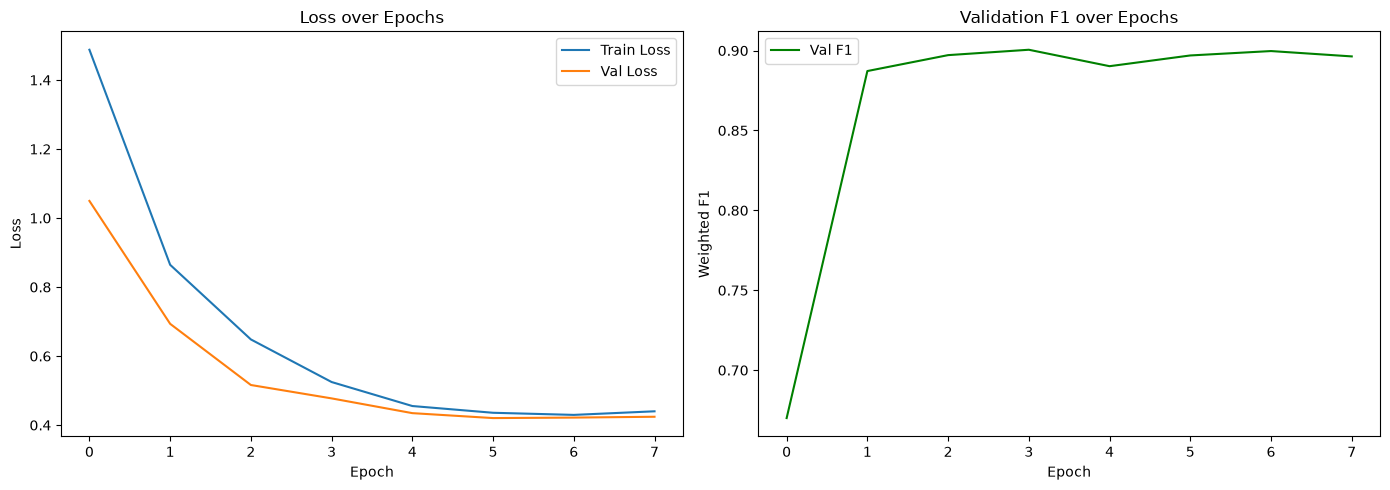

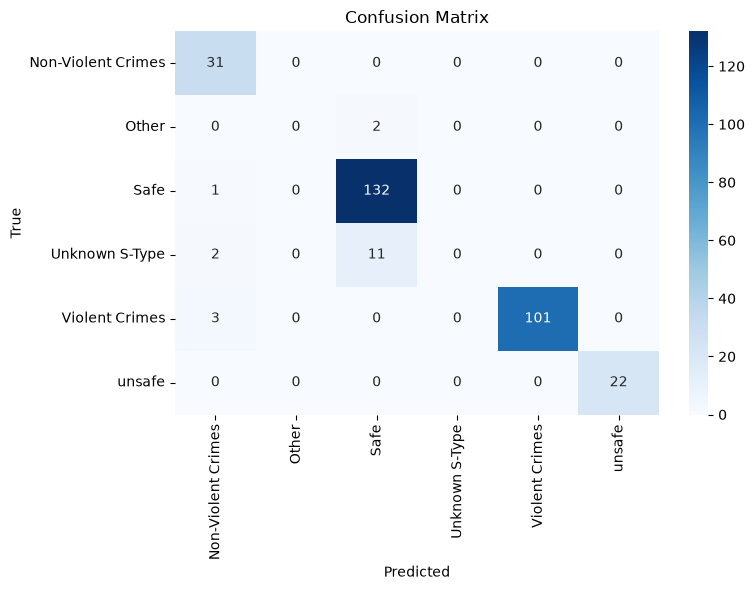

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Final evaluation on the TEST set ---
model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(batch_y.cpu().numpy())

test_f1 = f1_score(test_labels, test_preds, average='weighted')
print(f"Test Weighted F1: {test_f1:.4f}\n")

target_names = list(label_mapping.keys())
print(classification_report(test_labels, test_preds, target_names=target_names, zero_division=0))

# --- Plot 1: Loss & F1 curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['val_f1'], label='Val F1', color='green')
axes[1].set_title('Validation F1 over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weighted F1')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# --- Plot 2: Confusion matrix ---
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [14]:
import pickle

# Save the updated vocabulary
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

# Save the updated label encoder (which now has 6 classes)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Save the trained model weights
torch.save(model.state_dict(), 'best_model.pth')